# SIiIW — Lista 4: Klasyfikacja przeżywalności w marskości wątroby

Notebook realizuje **fazy 1–4** z `PLAN.md` na zbiorze UCI *„Cirrhosis Patient Survival Prediction"* (id=878):
418 pacjentów, 17 cech, **3 klasy** zmiennej `Status` — `C` (censored), `CL` (transplantacja), `D` (death).

**Założenia metodologiczne (z `CLAUDE.md`):**
- `ID` i `N_Days` są usuwane przez loader — `N_Days` to bezpośredni **wyciek targetu**.
- Klasy są silnie niezrównoważone (`CL` ≈ 6 %), więc raportujemy **macro-F1 obok accuracy**, a split i CV są **stratyfikowane**.
- Preprocessing dopasowujemy (`fit`) **wyłącznie na zbiorze treningowym** (Pipeline + ColumnTransformer wewnątrz CV).
- Standaryzacja **nie** jest porównywana jako „metoda przetwarzania" dla NB/drzewa (nie zmienia ich wyników) — porównujemy **selekcję cech (InfoGain)** i **PCA**; skalowanie pokazujemy osobno przy SVM.

> Kod, tabele i wykresy są wygenerowane w całości. Komórki **„Interpretacja"** zawierają tylko wypunktowanie, *co* opisać — wnioski wpisuje autor (`# TODO (Dawid)`).

## 0. Konfiguracja środowiska i import helperów z `src/`

In [1]:
import sys, os, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# notebook leży w katalogu projektu — dokładamy go do sys.path, by zaimportować pakiet src/
sys.path.insert(0, os.path.abspath("."))

from src import config
from src.load_data import load_data, missingness_report, split_X_y
from src.preprocess import make_preprocessor, base_column_transformer
from src.evaluate import compute_metrics

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
%matplotlib inline

RESULTS = config.RESULTS_DIR
RESULTS.mkdir(parents=True, exist_ok=True)
RND     = config.RANDOM_STATE
LABELS  = config.CLASS_LABELS          # ['C', 'CL', 'D']
SKF     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
SCORING = "f1_macro"                   # macro, bo klasa CL jest rzadka

def save_md(df, name, index=True):
    """Zapis wyswietlanej tabeli do results/: <name>.md (markdown do wklejenia
    w raporcie) ORAZ <name>.csv. Zwraca df, aby od razu go wyswietlic."""
    df.to_csv(RESULTS / f"{name}.csv", index=index)
    (RESULTS / f"{name}.md").write_text(df.to_markdown(index=index), encoding="utf-8")
    return df

print("sklearn", sklearn.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)
print("RANDOM_STATE =", RND, "| klasy:", LABELS, "| CV =", SKF)

sklearn 1.9.0 | pandas 3.0.2 | numpy 2.4.4
RANDOM_STATE = 42 | klasy: ['C', 'CL', 'D'] | CV = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 1. Eksploracja danych (EDA) · *10 pkt*

In [2]:
df = load_data(verbose=True)
print("Kształt:", df.shape, " → 17 cech + kolumna docelowa Status")
save_md(df.head(), "eda_head", index=False)

[load] lokalny CSV: D:\Projekty\siiw-lista4\siiw-lista4\data\cirrhosis.csv
[clean] usunięto kolumny (wyciek/ID): ['ID', 'N_Days']
[ok] kształt: (418, 18)  | cechy: 17
Kształt: (418, 18)  → 17 cech + kolumna docelowa Status


,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema,Stage,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin
0,D,D-penicillamine,F,Y,Y,Y,Y,4.0,21464,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2
1,C,D-penicillamine,F,N,Y,Y,N,3.0,20617,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6
2,D,D-penicillamine,M,N,N,N,S,4.0,25594,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0
3,D,D-penicillamine,F,N,Y,Y,S,4.0,19994,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3
4,CL,Placebo,F,N,Y,Y,N,3.0,13918,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9


In [3]:
# typy kolumn, liczba unikalnych wartości i braków — szybki przegląd
overview = pd.DataFrame({
    "dtype":     df.dtypes.astype(str),
    "n_unique":  df.nunique(dropna=True),
    "n_missing": df.isna().sum(),
})
save_md(overview, "eda_overview")

,dtype,n_unique,n_missing
Status,string,3,0
Drug,category,2,106
Sex,category,2,0
Ascites,category,2,106
Hepatomegaly,category,2,106
Spiders,category,2,106
Edema,category,3,0
Stage,category,4,6
Age,int64,344,0
Bilirubin,float64,98,0


### 1.1 Rozkład klasy docelowej `Status` (nierównowaga)

,liczność,udział_%
C,232,55.5
CL,25,6.0
D,161,38.5


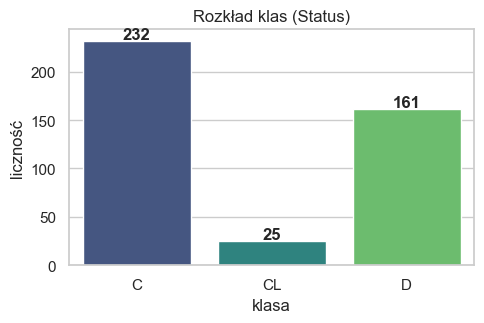

In [4]:
dist = df[config.TARGET].value_counts().reindex(LABELS)
vals = dist.astype(int).tolist()
dist_tbl = pd.DataFrame({"liczność": vals,
                         "udział_%": (dist / dist.sum() * 100).round(1).tolist()},
                        index=LABELS)
display(save_md(dist_tbl, "eda_target_dist"))

fig, ax = plt.subplots(figsize=(5, 3.4))
sns.barplot(x=LABELS, y=vals, hue=LABELS, palette="viridis", legend=False, ax=ax)
for i, v in enumerate(vals):
    ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
ax.set(title="Rozkład klas (Status)", xlabel="klasa", ylabel="liczność")
fig.tight_layout(); fig.savefig(RESULTS / "eda_target_dist.png", dpi=130); plt.show()

### 1.2 Statystyki opisowe cech liczbowych

In [5]:
num = [c for c in config.NUMERIC_FEATURES if c in df.columns]
desc = df[num].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

# Age jest w DNIACH → dla czytelności przelicz na lata
age_y = df["Age"] / 365.25
print(f"Wiek [lata]:  mean={age_y.mean():.1f}  min={age_y.min():.1f}  max={age_y.max():.1f}")
save_md(desc, "eda_numeric_describe")


Wiek [lata]:  mean=50.7  min=26.3  max=78.4


,mean,std,min,25%,50%,75%,max
Age,18533.35,3815.85,9598.00,15644.50,18628.00,21272.50,28650.00
Bilirubin,3.22,4.41,0.30,0.80,1.40,3.40,28.00
Cholesterol,369.51,231.94,120.00,249.50,309.50,400.00,1775.00
Albumin,3.50,0.42,1.96,3.24,3.53,3.77,4.64
Copper,97.65,85.61,4.00,41.25,73.00,123.00,588.00
Alk_Phos,1982.66,2140.39,289.00,871.50,1259.00,1980.00,13862.40
SGOT,122.56,56.70,26.35,80.60,114.70,151.90,457.25
Tryglicerides,124.70,65.15,33.00,84.25,108.00,151.00,598.00
Platelets,257.02,98.33,62.00,188.50,251.00,318.00,721.00
Prothrombin,10.73,1.02,9.00,10.00,10.60,11.10,18.00


### 1.3 Rozkłady cech kategorycznych


=== Drug ===


,liczność,udział_%
Drug,,
D-penicillamine,158,37.8
Placebo,154,36.8
NaN,106,25.4



=== Sex ===


,liczność,udział_%
Sex,,
F,374,89.5
M,44,10.5



=== Ascites ===


...

,liczność,udział_%
Spiders,,
N,222,53.1
NaN,106,25.4
Y,90,21.5



=== Edema ===


,liczność,udział_%
Edema,,
N,354,84.7
S,44,10.5
Y,20,4.8



=== Stage ===


,liczność,udział_%
Stage,,
3.0,155,37.1
4.0,144,34.4
2.0,92,22.0
1.0,21,5.0
NaN,6,1.4


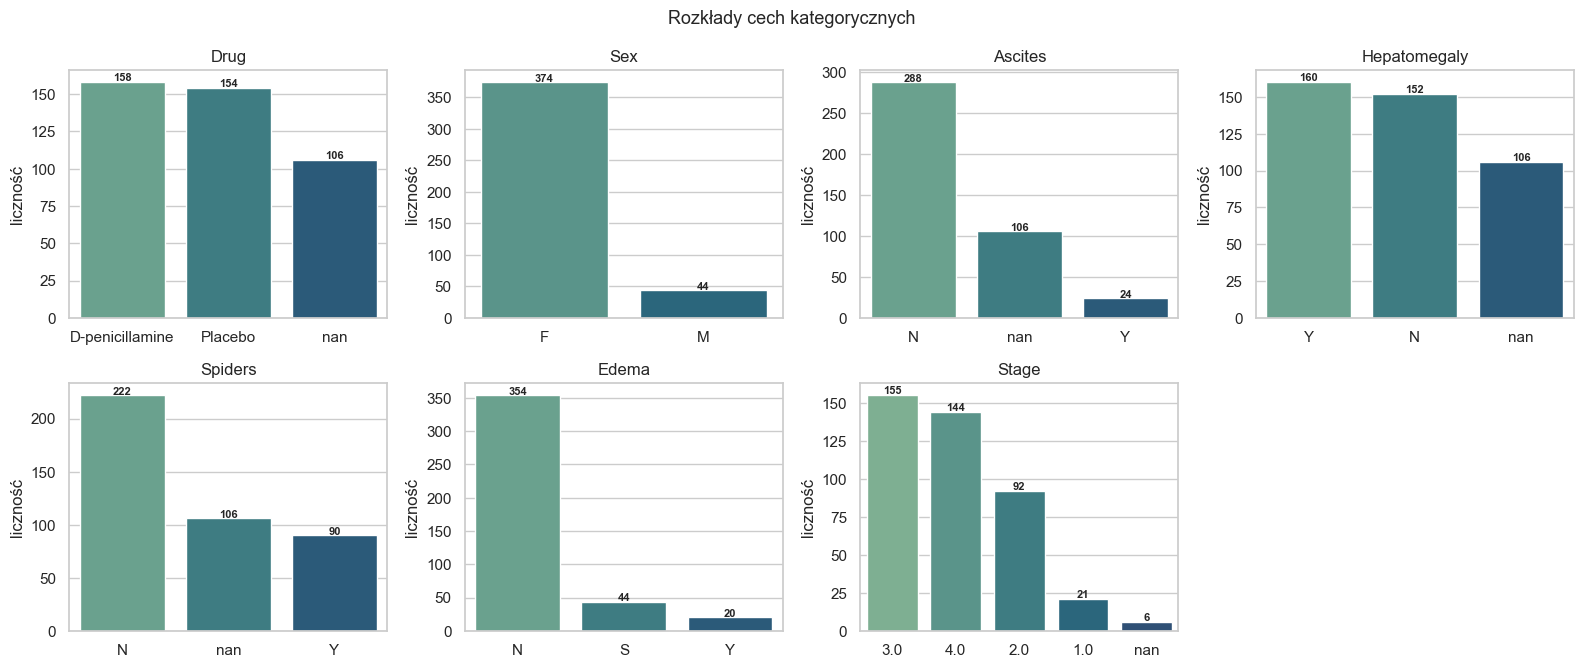

In [6]:
# Rozklad KAZDEJ cechy kategorycznej: tabela value_counts (licznosc + udzial %)
# oraz wykres slupkowy. Cechy kategoryczne opisujemy ROZKLADEM, nie statystykami
# liczbowymi (describe ich nie dotyczy) — to wymog prowadzacej.
cat = [c for c in config.CATEGORICAL_FEATURES if c in df.columns]

cat_long = []                                  # zbiorcza tabela dluga (do raportu)
for c in cat:
    cnt = df[c].value_counts(dropna=False)
    pct = (cnt / len(df) * 100).round(1)
    tbl = pd.DataFrame({"liczność": cnt.astype(int), "udział_%": pct})
    tbl.index.name = c
    save_md(tbl, f"eda_cat_{c.lower()}")        # osobna tabela md+csv na cechę
    print(f"\n=== {c} ===")
    display(tbl)
    for (k, v), p in zip(cnt.items(), pct.tolist()):
        cat_long.append({"cecha": c, "wartość": str(k),
                         "liczność": int(v), "udział_%": p})

cat_tbl = pd.DataFrame(cat_long)
save_md(cat_tbl, "eda_categorical_all", index=False)   # jedna zbiorcza tabela

# wykresy slupkowe — po jednym panelu na ceche
ncol = 4
nrow = int(np.ceil(len(cat) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.4 * nrow))
axes = np.array(axes).reshape(-1)
for ax, c in zip(axes, cat):
    vc = df[c].value_counts(dropna=False)
    order = [str(i) for i in vc.index]
    sns.barplot(x=order, y=vc.values, hue=order, palette="crest", legend=False, ax=ax)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 1, str(int(v)), ha="center", fontsize=8, fontweight="bold")
    ax.set(title=c, xlabel="", ylabel="liczność")
for ax in axes[len(cat):]:
    ax.set_visible(False)
fig.suptitle("Rozkłady cech kategorycznych", fontsize=13)
fig.tight_layout(); fig.savefig(RESULTS / "eda_categorical_dist.png", dpi=130); plt.show()


### 1.4 Mapa braków danych

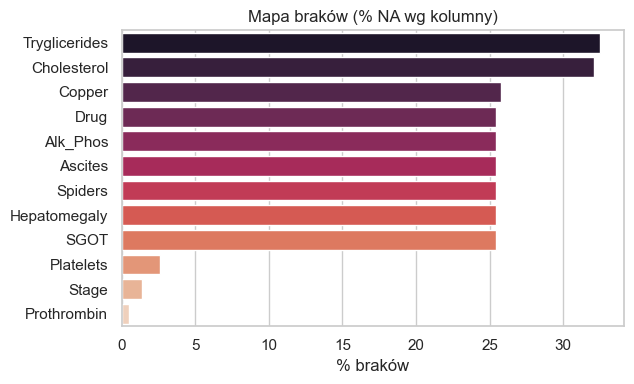

,n_missing,pct_missing
Tryglicerides,136,32.5
Cholesterol,134,32.1
Copper,108,25.8
Drug,106,25.4
Alk_Phos,106,25.4
Ascites,106,25.4
Spiders,106,25.4
Hepatomegaly,106,25.4
SGOT,106,25.4
Platelets,11,2.6


In [7]:
miss = missingness_report(df)

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(x=miss["pct_missing"].values, y=miss.index.tolist(),
            hue=miss.index.tolist(), palette="rocket", legend=False, ax=ax)
ax.set(title="Mapa braków (% NA wg kolumny)", xlabel="% braków", ylabel="")
fig.tight_layout(); fig.savefig(RESULTS / "eda_missingness.png", dpi=130); plt.show()
display(save_md(miss, "eda_missingness"))

### 1.5 Korelacje cech liczbowych

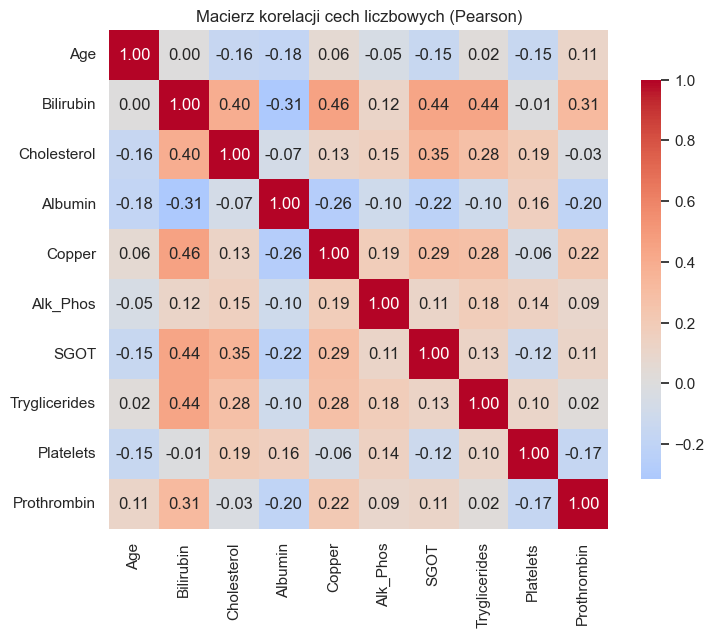

In [8]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[num].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Macierz korelacji cech liczbowych (Pearson)")
fig.tight_layout(); fig.savefig(RESULTS / "eda_corr.png", dpi=130); plt.show()

### 1.6 Skośność i separacja klas (cechy klinicznie istotne)

Skośność cech liczbowych (malejąco):
Cholesterol      3.41
Alk_Phos         2.99
Bilirubin        2.72
Tryglicerides    2.52
Copper           2.30
Prothrombin      2.22
SGOT             1.45
Platelets        0.63
Age              0.09
Albumin         -0.47


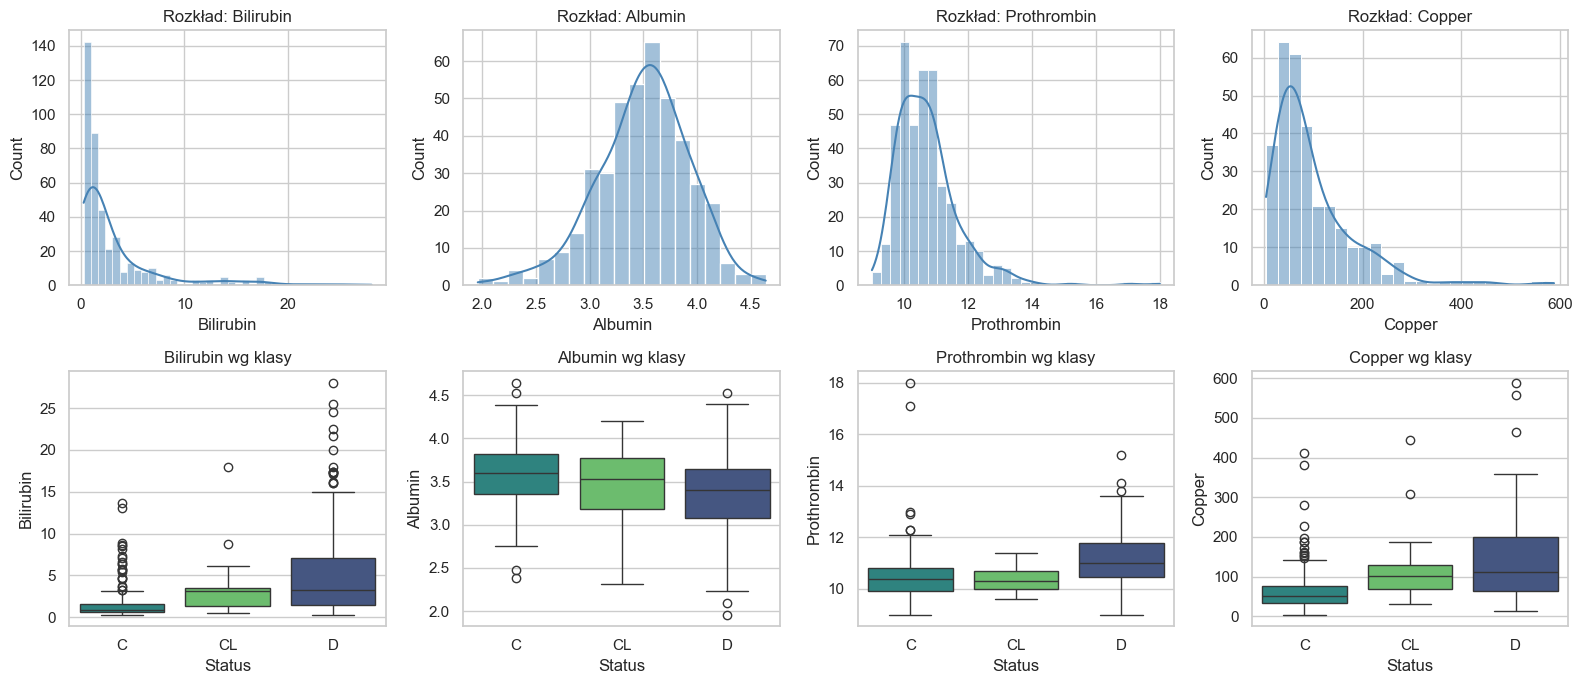

In [9]:
skew = df[num].skew().sort_values(ascending=False)
print("Skośność cech liczbowych (malejąco):")
print(skew.round(2).to_string())

key_feats = ["Bilirubin", "Albumin", "Prothrombin", "Copper"]
fig, axes = plt.subplots(2, len(key_feats), figsize=(4 * len(key_feats), 7))
for j, f in enumerate(key_feats):
    sns.histplot(df[f].dropna(), kde=True, color="steelblue", ax=axes[0, j])
    axes[0, j].set_title(f"Rozkład: {f}")
    sns.boxplot(data=df, x=config.TARGET, y=f, order=LABELS,
                hue=config.TARGET, palette="viridis", legend=False, ax=axes[1, j])
    axes[1, j].set_title(f"{f} wg klasy")
fig.tight_layout(); fig.savefig(RESULTS / "eda_feature_by_class.png", dpi=130); plt.show()

### 📝 Interpretacja EDA — *(do uzupełnienia — Dawid)*

`# TODO (Dawid)` — w 3–5 zdaniach, na podstawie powyższych tabel i wykresów, opisz:
- **Nierównowaga klas:** jak rzadka jest `CL` (% z tabeli rozkładu) i co to znaczy dla doboru metryk (dlaczego sama accuracy nie wystarczy).
- **Skośność cech:** które cechy są silnie prawostronnie skośne (tabela skośności / histogramy — np. `Bilirubin`, `Alk_Phos`) i jak to rzutuje na założenie normalności w `GaussianNB`.
- **Braki danych:** skala braków (mapa braków) i grupa ~25 % pacjentów spoza badania klinicznego (kolumna `Drug`).
- **Korelacje:** które pary cech są ze sobą skorelowane (heatmapa) — ryzyko współliniowości.
- **Cechy separujące klasy:** które cechy na boxplotach najlepiej rozdzielają `C`/`CL`/`D` (kandydaci: `Bilirubin`, `Albumin`, `Prothrombin`).

## 2. Przygotowanie danych · *30 pkt*

### 2.1 Stratyfikowany podział train / holdout

In [10]:
X, y = split_X_y(df)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RND)
print(f"train = {len(X_tr)}   holdout (walidacyjny) = {len(X_te)}   (stratify=y, test_size=0.2)")

# kontrola: stratyfikacja zachowuje proporcje klas w obu podzbiorach
prop = pd.DataFrame({
    "train_%":   y_tr.value_counts(normalize=True).reindex(LABELS).mul(100).round(1),
    "holdout_%": y_te.value_counts(normalize=True).reindex(LABELS).mul(100).round(1),
})
save_md(prop, "split_class_proportions")


train = 334   holdout (walidacyjny) = 84   (stratify=y, test_size=0.2)


,train_%,holdout_%
Status,,
C,55.4,56.0
CL,6.0,6.0
D,38.6,38.1


### 2.2 Postępowanie z brakami danych

Realizowane przez `ColumnTransformer` (fit tylko na train):
- **liczbowe** → `SimpleImputer(strategy="median")` (odporna na skośność),
- **kategoryczne** → `SimpleImputer(strategy="constant", fill_value="Missing")` — brak jako **osobna kategoria**,
  co zachowuje informację o ~25 % pacjentów spoza badania (m.in. cała kolumna `Drug`), zamiast usuwać wiersze.

`# TODO (Dawid)` — uzasadnij wybór imputacji vs usuwanie wierszy oraz decyzję o `Drug` (osobna kategoria „Missing").

### 2.3 Trzy warianty przetwarzania (baseline + selekcja cech + PCA)

In [11]:
# struktura każdego pipeline'u przetwarzania (kroki przed klasyfikatorem)
for v in ["baseline", "feature_select", "pca"]:
    steps = make_preprocessor(v)
    print(f"{v:15s} ->  " + "  ->  ".join(name for name, _ in steps))

print("\nLiczba cech wchodzących do klasyfikatora (po dopasowaniu na train):")
for v in ["baseline", "feature_select", "pca"]:
    pipe = Pipeline(make_preprocessor(v) + [("clf", GaussianNB())]).fit(X_tr, y_tr)
    n_out = Pipeline(pipe.steps[:-1]).transform(X_tr).shape[1]
    print(f"  {v:15s}: {n_out} cech")

baseline        ->  prep
feature_select  ->  prep  ->  select
pca             ->  prep  ->  pca

Liczba cech wchodzących do klasyfikatora (po dopasowaniu na train):
  baseline       : 32 cech
  feature_select : 12 cech
  pca            : 8 cech


| Wariant | Co robi | Po co |
|---|---|---|
| **baseline** | imputacja + one-hot (num. `passthrough`) | punkt odniesienia |
| **feature_select** | + `SelectKBest(mutual_info_classif, k=12)` ≈ InfoGain | mniej cech, redukcja szumu |
| **pca** | + `StandardScaler` → `PCA(n_components=8)` | dekorelacja, redukcja wymiaru |

### 2.4 Tabela porównawcza: baseline vs selekcja vs PCA × {NB, drzewo}

In [12]:
# porównanie na DOMYŚLNYCH hiperparametrach, uczciwie przez 5-krotną stratyfikowaną CV na train
def cv_eval(make_clf, variant):
    pipe = Pipeline(make_preprocessor(variant) + [("clf", make_clf())])
    r = cross_validate(pipe, X_tr, y_tr, cv=SKF,
                       scoring=["f1_macro", "accuracy", "f1_weighted"])
    return {"f1_macro_cv":   r["test_f1_macro"].mean(),
            "f1_macro_std":  r["test_f1_macro"].std(),
            "accuracy_cv":   r["test_accuracy"].mean(),
            "f1_weighted_cv": r["test_f1_weighted"].mean()}

factories = {"GaussianNB":   lambda: GaussianNB(),
             "DecisionTree": lambda: DecisionTreeClassifier(random_state=RND)}

rows = []
for variant in ["baseline", "feature_select", "pca"]:
    for mname, fac in factories.items():
        m = cv_eval(fac, variant)
        rows.append({"model": mname, "preprocessing": variant,
                     **{k: round(v, 4) for k, v in m.items()}})

prep_cmp = (pd.DataFrame(rows)
            .sort_values(["model", "f1_macro_cv"], ascending=[True, False])
            .reset_index(drop=True))
save_md(prep_cmp, "preprocessing_comparison", index=False)


,model,preprocessing,f1_macro_cv,f1_macro_std,accuracy_cv,f1_weighted_cv
0,DecisionTree,feature_select,0.5062,0.0982,0.6436,0.6401
1,DecisionTree,baseline,0.4829,0.0477,0.6257,0.6297
2,DecisionTree,pca,0.4056,0.0304,0.5869,0.5837
3,GaussianNB,baseline,0.5191,0.0350,0.6497,0.6574
4,GaussianNB,feature_select,0.4949,0.0842,0.6676,0.6544
5,GaussianNB,pca,0.4699,0.0337,0.7065,0.6757


### 📝 Interpretacja przetwarzania — *(do uzupełnienia — Dawid)*

`# TODO (Dawid)` — na podstawie tabeli `preprocessing_comparison`:
- która metoda (selekcja cech / PCA) **poprawiła**, a która **pogorszyła** wynik względem baseline — osobno dla NB i drzewa,
- dlaczego (np. PCA dekoreluje cechy, co pomaga NB zakładającemu niezależność; selekcja usuwa szum),
- przypomnij, **dlaczego standaryzacja nie była** osobną metodą dla NB/drzewa (identyczne wyniki — drzewo niezmiennicze na skalę, NB modeluje każdą cechę osobno).

## 3. Klasyfikacja (strojenie hiperparametrów)

Strojenie: `GridSearchCV` po **`f1_macro`** na **`StratifiedKFold(5)`**. Baseline jako preprocessing
(selekcja/PCA porównane wyżej). Każdy klasyfikator strojony na **≥3 zestawach hiperparametrów**.

### 3.1 Naiwny klasyfikator Bayesa (`GaussianNB`)

In [13]:
nb_pipe = Pipeline(make_preprocessor("baseline") + [("clf", GaussianNB())])
nb_grid = {"clf__var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3]}   # 4 zestawy (>=3)
nb_gs = GridSearchCV(nb_pipe, nb_grid, scoring=SCORING, cv=SKF,
                     n_jobs=1, return_train_score=True)
nb_gs.fit(X_tr, y_tr)

nb_res = (pd.DataFrame(nb_gs.cv_results_)
          [["param_clf__var_smoothing", "mean_test_score", "std_test_score",
            "mean_train_score", "rank_test_score"]]
          .sort_values("rank_test_score").reset_index(drop=True))
nb_res.columns = ["var_smoothing", "f1_macro_cv", "std", "f1_macro_train", "rank"]
print("Najlepsze NB:", nb_gs.best_params_, "| f1_macro CV =", round(nb_gs.best_score_, 4))
save_md(nb_res, "tuning_nb", index=False)


Najlepsze NB: {'clf__var_smoothing': 1e-09} | f1_macro CV = 0.5191


,var_smoothing,f1_macro_cv,std,f1_macro_train,rank
0,1.000000e-09,0.519138,0.035045,0.607968,1
1,1.000000e-07,0.506395,0.071849,0.547613,2
2,1.000000e-05,0.462383,0.064834,0.515202,3
3,1.000000e-03,0.374855,0.038936,0.418275,4


### 3.2 Drzewo decyzyjne (`DecisionTreeClassifier`)

In [14]:
dt_pipe = Pipeline(make_preprocessor("baseline") +
                   [("clf", DecisionTreeClassifier(random_state=RND))])
dt_grid = {"clf__criterion":        ["gini", "entropy"],
           "clf__max_depth":        [3, 5, 10, None],
           "clf__min_samples_leaf": [1, 5, 10]}            # 2*4*3 = 24 zestawy
dt_gs = GridSearchCV(dt_pipe, dt_grid, scoring=SCORING, cv=SKF,
                     n_jobs=1, return_train_score=True)
dt_gs.fit(X_tr, y_tr)

dt_res = (pd.DataFrame(dt_gs.cv_results_)
          [["param_clf__criterion", "param_clf__max_depth", "param_clf__min_samples_leaf",
            "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]]
          .sort_values("rank_test_score").reset_index(drop=True))
dt_res.columns = ["criterion", "max_depth", "min_samples_leaf",
                  "f1_macro_cv", "std", "f1_macro_train", "rank"]
print("Najlepsze drzewo:", dt_gs.best_params_, "| f1_macro CV =", round(dt_gs.best_score_, 4))
save_md(dt_res.head(10), "tuning_dt", index=False)

Najlepsze drzewo: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 5} | f1_macro CV = 0.5405


,criterion,max_depth,min_samples_leaf,f1_macro_cv,std,f1_macro_train,rank
0,entropy,10,5,0.540549,0.075312,0.812628,1
1,entropy,None,5,0.539504,0.076912,0.813294,2
2,entropy,5,1,0.534901,0.083678,0.831657,3
3,entropy,5,5,0.531919,0.105338,0.775883,4
4,entropy,None,1,0.524519,0.095075,1.000000,5
5,entropy,10,1,0.522115,0.093141,0.994502,6
6,entropy,5,10,0.507403,0.058503,0.650120,7
7,gini,10,1,0.506708,0.054472,0.971359,8
8,entropy,None,10,0.503059,0.046515,0.654286,9
9,entropy,10,10,0.503059,0.046515,0.654286,9


### 3.3 Krzywa głębokości drzewa: train vs walidacja (przeuczenie)

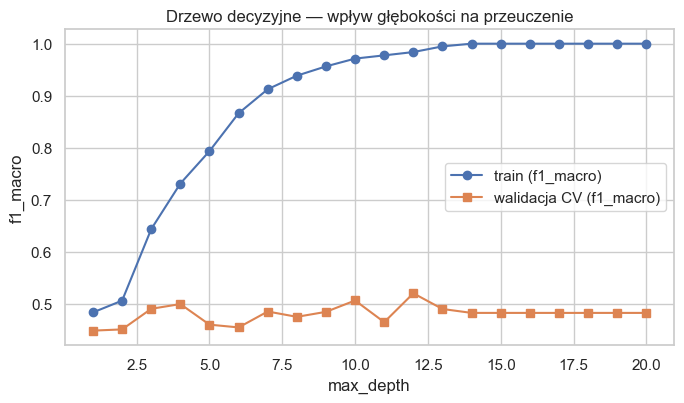

In [15]:
depth_range = list(range(1, 21))
tr_curve, val_curve = [], []
for d in depth_range:
    p = Pipeline(make_preprocessor("baseline") +
                 [("clf", DecisionTreeClassifier(max_depth=d, random_state=RND))])
    r = cross_validate(p, X_tr, y_tr, cv=SKF, scoring=SCORING, return_train_score=True)
    tr_curve.append(r["train_score"].mean())
    val_curve.append(r["test_score"].mean())

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(depth_range, tr_curve,  "o-", label="train (f1_macro)")
ax.plot(depth_range, val_curve, "s-", label="walidacja CV (f1_macro)")
ax.set(xlabel="max_depth", ylabel="f1_macro",
       title="Drzewo decyzyjne — wpływ głębokości na przeuczenie")
ax.legend(); fig.tight_layout()
fig.savefig(RESULTS / "dt_depth_curve.png", dpi=130); plt.show()

### 📝 Interpretacja strojenia — *(do uzupełnienia — Dawid)*

`# TODO (Dawid)`:
- wskaż najlepszy zestaw hiperparametrów NB i drzewa (z tabel `nb_res` / `dt_res`),
- z krzywej głębokości: przy jakim `max_depth` rośnie różnica train–walidacja (objaw przeuczenia) i gdzie walidacja ma maksimum.

### 3.4 Bonus *(+5)* — algorytmy zaawansowane: Random Forest

In [16]:
rf_pipe = Pipeline(make_preprocessor("baseline") +
                   [("clf", RandomForestClassifier(random_state=RND))])
rf_grid = {"clf__n_estimators":     [100, 300],
           "clf__max_depth":        [5, 10, None],
           "clf__min_samples_leaf": [1, 5]}
rf_gs = GridSearchCV(rf_pipe, rf_grid, scoring=SCORING, cv=SKF, n_jobs=1)
rf_gs.fit(X_tr, y_tr)
rf_res = (pd.DataFrame(rf_gs.cv_results_)
          [["param_clf__n_estimators", "param_clf__max_depth",
            "param_clf__min_samples_leaf", "mean_test_score", "rank_test_score"]]
          .sort_values("rank_test_score").reset_index(drop=True))
rf_res.columns = ["n_estimators", "max_depth", "min_samples_leaf", "f1_macro_cv", "rank"]
print("Najlepszy RF:", rf_gs.best_params_, "| f1_macro CV =", round(rf_gs.best_score_, 4))
save_md(rf_res.head(8), "tuning_rf", index=False)

Najlepszy RF: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100} | f1_macro CV = 0.5072


,n_estimators,max_depth,min_samples_leaf,f1_macro_cv,rank
0,100,5,1,0.507164,1
1,100,5,5,0.505244,2
2,300,10,1,0.502087,3
3,300,5,1,0.501108,4
4,300,None,1,0.500074,5
5,300,10,5,0.498238,6
6,100,None,5,0.496509,7
7,300,None,5,0.495842,8


### 3.5 Bonus *(+5)* — SVM (rola skalowania)

In [17]:
# SVM liczy odległości / iloczyny skalarne między próbkami, więc cechy o większej skali
# zdominują te o mniejszej -> SVM WYMAGA standaryzacji (StandardScaler).
# Drzewo decyzyjne dzieli po progach pojedynczych cech i jest niezmiennicze na monotoniczne
# przeskalowanie -> skalowania NIE potrzebuje (dlatego pomijamy je dla NB/drzewa).
svm_prep = [("prep", base_column_transformer(scale_numeric=True))]   # skalowanie cech liczbowych
svm_pipe = Pipeline(svm_prep + [("clf", SVC(random_state=RND))])
svm_grid = {"clf__C":      [0.1, 1, 10],
            "clf__kernel": ["rbf", "linear"],
            "clf__gamma":  ["scale", "auto"]}
svm_gs = GridSearchCV(svm_pipe, svm_grid, scoring=SCORING, cv=SKF, n_jobs=1)
svm_gs.fit(X_tr, y_tr)
svm_res = (pd.DataFrame(svm_gs.cv_results_)
           [["param_clf__C", "param_clf__kernel", "param_clf__gamma",
             "mean_test_score", "rank_test_score"]]
           .sort_values("rank_test_score").reset_index(drop=True))
svm_res.columns = ["C", "kernel", "gamma", "f1_macro_cv", "rank"]
print("Najlepszy SVM:", svm_gs.best_params_, "| f1_macro CV =", round(svm_gs.best_score_, 4))

# demonstracja wpływu skalowania (ten sam SVC, domyślne hiperparametry)
r_ns = cross_validate(Pipeline([("prep", base_column_transformer(scale_numeric=False)),
                                ("clf", SVC(random_state=RND))]), X_tr, y_tr, cv=SKF, scoring=SCORING)
r_s  = cross_validate(Pipeline([("prep", base_column_transformer(scale_numeric=True)),
                                ("clf", SVC(random_state=RND))]), X_tr, y_tr, cv=SKF, scoring=SCORING)
print(f"  SVM bez skalowania : f1_macro CV = {r_ns['test_score'].mean():.4f}")
print(f"  SVM ze skalowaniem : f1_macro CV = {r_s['test_score'].mean():.4f}")
save_md(svm_res.head(8), "tuning_svm", index=False)

Najlepszy SVM: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'} | f1_macro CV = 0.541
  SVM bez skalowania : f1_macro CV = 0.2906
  SVM ze skalowaniem : f1_macro CV = 0.4895


,C,kernel,gamma,f1_macro_cv,rank
0,10.0,linear,auto,0.541003,1
1,10.0,linear,scale,0.541003,1
2,1.0,linear,auto,0.530991,3
3,1.0,linear,scale,0.530991,3
4,10.0,rbf,auto,0.515408,5
5,10.0,rbf,scale,0.509475,6
6,1.0,rbf,auto,0.498164,7
7,0.1,linear,scale,0.495544,8


### 3.6 Bonus *(+5)* — złagodzenie przeuczenia drzewa (`ccp_alpha`)

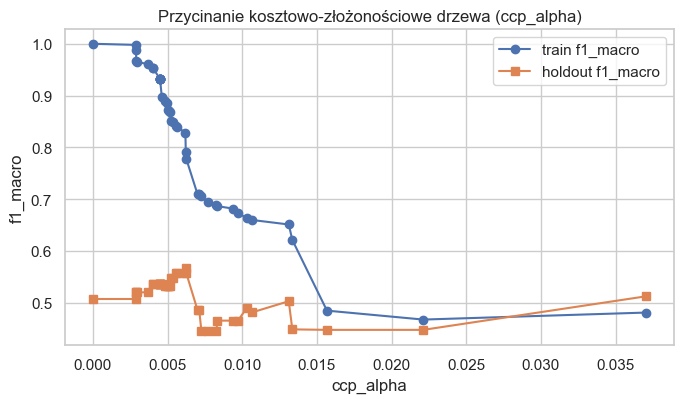

Wybrane ccp_alpha = 0.00621


,konfiguracja,train_f1_macro,holdout_f1_macro,różnica_train-holdout
0,drzewo pełne (ccp_alpha≈0),1.000,0.5074,0.4926
1,drzewo przycięte (ccp_alpha=0.00621),0.792,0.5671,0.2249


In [18]:
# preprocessing dopasowany TYLKO na train (brak wycieku), holdout tylko transform
prep_dt = base_column_transformer(scale_numeric=False)
Xtr_t = prep_dt.fit_transform(X_tr, y_tr)
Xte_t = prep_dt.transform(X_te)

# ścieżka kosztowo-złożonościowa: rosnące alpha = mocniejsze przycinanie
full_tree = DecisionTreeClassifier(random_state=RND).fit(Xtr_t, y_tr)
alphas = full_tree.cost_complexity_pruning_path(Xtr_t, y_tr).ccp_alphas[:-1]  # bez trywialnego korzenia
if len(alphas) > 40:
    alphas = alphas[::max(1, len(alphas) // 40)]

tr_f1, te_f1 = [], []
for a in alphas:
    t = DecisionTreeClassifier(random_state=RND, ccp_alpha=a).fit(Xtr_t, y_tr)
    tr_f1.append(f1_score(y_tr, t.predict(Xtr_t), average="macro"))
    te_f1.append(f1_score(y_te, t.predict(Xte_t), average="macro"))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(alphas, tr_f1, "o-", label="train f1_macro")
ax.plot(alphas, te_f1, "s-", label="holdout f1_macro")
ax.set(xlabel="ccp_alpha", ylabel="f1_macro",
       title="Przycinanie kosztowo-złożonościowe drzewa (ccp_alpha)")
ax.legend(); fig.tight_layout()
fig.savefig(RESULTS / "overfitting_mitigation.png", dpi=130); plt.show()

# wybór alpha maksymalizującego f1_macro na holdout; porównaj różnicę train-holdout
best_i = int(np.argmax(te_f1))
best_alpha = float(alphas[best_i])
gap = pd.DataFrame({
    "konfiguracja":     ["drzewo pełne (ccp_alpha≈0)", f"drzewo przycięte (ccp_alpha={best_alpha:.5f})"],
    "train_f1_macro":   [round(tr_f1[0], 4),  round(tr_f1[best_i], 4)],
    "holdout_f1_macro": [round(te_f1[0], 4),  round(te_f1[best_i], 4)],
})
gap["różnica_train-holdout"] = (gap["train_f1_macro"] - gap["holdout_f1_macro"]).round(4)
print(f"Wybrane ccp_alpha = {best_alpha:.5f}")
save_md(gap, "overfitting_gap", index=False)


### 📝 Interpretacja bonusów — *(do uzupełnienia — Dawid)*

`# TODO (Dawid)`:
- **RF/SVM:** czy bije podstawowe modele (porównaj `f1_macro_cv`); krótko czemu (zespół drzew / margines),
- **skalowanie SVM:** odnieś się do dwóch liczb „bez/ze skalowaniem" — potwierdź, że skalowanie ma znaczenie dla SVM, a drzewo go nie wymaga,
- **ccp_alpha:** o ile zmalała **różnica train–holdout** po przycięciu (tabela `gap`) i czy walidacja nie spadła zbytnio.

## 4. Ewaluacja na zbiorze holdout · *20 pkt*

Dla **najlepszej konfiguracji każdego modelu** liczymy na holdoucie: accuracy, precision/recall/F1
(**macro i weighted**), F1 per-klasa oraz **macierz pomyłek 3×3**.

In [19]:
# najlepsze estymatory (GridSearchCV refit=True) + przycięte drzewo z bonusu
pruned_pipe = Pipeline(make_preprocessor("baseline") +
                       [("clf", DecisionTreeClassifier(random_state=RND, ccp_alpha=best_alpha))]
                       ).fit(X_tr, y_tr)

best_models = {
    "GaussianNB (strojony)":        nb_gs.best_estimator_,
    "DecisionTree (strojony)":      dt_gs.best_estimator_,
    "DecisionTree (ccp przycięte)": pruned_pipe,
    "RandomForest (strojony)":      rf_gs.best_estimator_,
    "SVM (skalowany, strojony)":    svm_gs.best_estimator_,
}

def eval_holdout(name, model):
    yp = model.predict(X_te)
    m = compute_metrics(y_te, yp, labels=LABELS)          # ACC + macro P/R/F1 + f1_weighted + per-klasa
    m["precision_weighted"] = round(precision_score(y_te, yp, average="weighted", zero_division=0), 4)
    m["recall_weighted"]    = round(recall_score(y_te, yp, average="weighted", zero_division=0), 4)
    return {"model": name, **m}

final_rows = [eval_holdout(n, m) for n, m in best_models.items()]
print("Policzono metryki holdout dla", len(final_rows), "konfiguracji.")

Policzono metryki holdout dla 5 konfiguracji.


### 4.1 Raporty per-klasa (NB i drzewo — wymagane)

In [20]:
for name in ["GaussianNB (strojony)", "DecisionTree (strojony)"]:
    yp = best_models[name].predict(X_te)
    rep = pd.DataFrame(classification_report(
        y_te, yp, labels=LABELS, output_dict=True, zero_division=0)).T.round(3)
    slug = re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")
    print(f"### {name}")
    display(save_md(rep, f"classreport_{slug}"))

### GaussianNB (strojony)


,precision,recall,f1-score,support
C,0.717,0.809,0.760,47.000
CL,0.111,0.200,0.143,5.000
D,0.682,0.469,0.556,32.000
accuracy,0.643,0.643,0.643,0.643
macro avg,0.503,0.492,0.486,84.000
weighted avg,0.668,0.643,0.645,84.000


### DecisionTree (strojony)


,precision,recall,f1-score,support
C,0.717,0.809,0.760,47.000
CL,0.000,0.000,0.000,5.000
D,0.615,0.500,0.552,32.000
accuracy,0.643,0.643,0.643,0.643
macro avg,0.444,0.436,0.437,84.000
weighted avg,0.636,0.643,0.635,84.000


### 4.2 Macierze pomyłek 3×3 (wszystkie najlepsze modele)

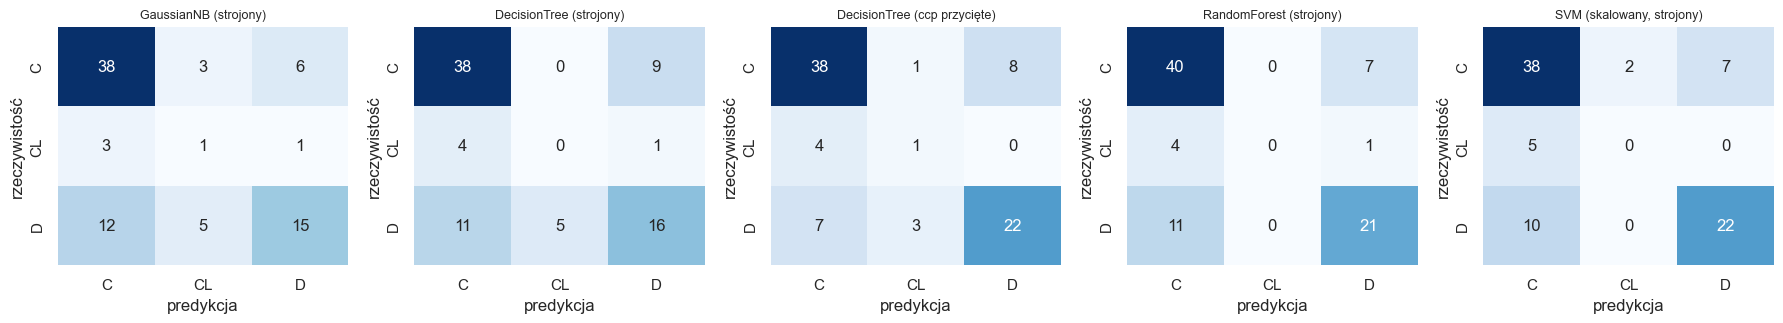

In [21]:
n = len(best_models)
fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 3.4))
for ax, (name, model) in zip(np.atleast_1d(axes), best_models.items()):
    yp = model.predict(X_te)
    cm = confusion_matrix(y_te, yp, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set(xlabel="predykcja", ylabel="rzeczywistość")
    ax.set_title(name, fontsize=9)
    # zapis pojedynczej macierzy do results/
    slug = re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")
    f2, a2 = plt.subplots(figsize=(3.6, 3.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=a2)
    a2.set(title=name, xlabel="predykcja", ylabel="rzeczywistość")
    f2.tight_layout(); f2.savefig(RESULTS / f"cm_{slug}.png", dpi=130); plt.close(f2)
fig.tight_layout(); fig.savefig(RESULTS / "cm_all_best.png", dpi=130); plt.show()

### 4.3 Tabela zbiorcza — najlepsze konfiguracje

In [22]:
final = pd.DataFrame(final_rows)
cols = ["model", "accuracy",
        "precision_macro", "recall_macro", "f1_macro",
        "precision_weighted", "recall_weighted", "f1_weighted",
        "f1_C", "f1_CL", "f1_D"]
final = final[cols].sort_values("f1_macro", ascending=False).reset_index(drop=True)
save_md(final, "final_metrics", index=False)


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,f1_C,f1_CL,f1_D
0,DecisionTree (ccp przycięte),0.7262,0.5696,0.5653,0.5671,0.7252,0.7262,0.7252,0.7917,0.2000,0.7097
1,"SVM (skalowany, strojony)",0.7143,0.4919,0.4987,0.4938,0.6902,0.7143,0.7000,0.7600,0.0000,0.7213
2,RandomForest (strojony),0.7262,0.4838,0.5024,0.4909,0.6828,0.7262,0.7011,0.7843,0.0000,0.6885
3,GaussianNB (strojony),0.6429,0.5033,0.4924,0.4861,0.6675,0.6429,0.6454,0.7600,0.1429,0.5556
4,DecisionTree (strojony),0.6429,0.4441,0.4362,0.4372,0.6356,0.6429,0.6354,0.7600,0.0000,0.5517


### 📝 Interpretacja ewaluacji — *(do uzupełnienia — Dawid)*

`# TODO (Dawid)` — z tabeli `final` i macierzy pomyłek:
- **accuracy vs f1_macro:** dlaczego się rozjeżdżają (udział klasy `CL`, kolumny `f1_CL` vs `f1_C`/`f1_D`),
- **klasa CL:** z czym jest mylona (które komórki macierzy pomyłek poza przekątną) i dlaczego (mało próbek),
- **NB vs drzewo:** założenia, mocne/słabe strony na tych danych,
- **zwycięska konfiguracja:** który model + preprocessing wygrał wg `f1_macro` i czy bonusy (RF/SVM, ccp) pomogły.

---
### Wygenerowane artefakty (results/)

Każda **wyświetlana tabela** jest zapisywana przez helper save_md() w dwóch formatach: <name>.csv oraz <name>.md (markdown gotowy do wklejenia do report/raport_szablon.md).

**Tabele (.md + .csv):**
- EDA: eda_head, eda_overview, eda_target_dist, eda_numeric_describe, eda_missingness, eda_categorical_all oraz eda_cat_<cecha> dla KAŻDEJ cechy kategorycznej (drug, sex, ascites, hepatomegaly, spiders, edema, stage)
- Przygotowanie danych: split_class_proportions, preprocessing_comparison
- Strojenie: tuning_nb, tuning_dt, tuning_rf, tuning_svm
- Bonus / ewaluacja: overfitting_gap, classreport_<model>, final_metrics

**Wykresy (.png):** eda_target_dist, eda_categorical_dist (rozkłady cech kategorycznych), eda_missingness, eda_corr, eda_feature_by_class, dt_depth_curve, overfitting_mitigation, cm_*, cm_all_best

Pełna, pogrupowana lista plików jest drukowana przez ostatnią komórkę kodu poniżej.

In [23]:
# Lista wygenerowanych artefaktow w results/ — pogrupowana wg typu
# (kontrola kompletnosci + sciaga, ktory plik wkleic do raportu).
arte = sorted(p.name for p in RESULTS.iterdir() if p.is_file())
groups = {"CSV (.csv)": ".csv", "Markdown (.md)": ".md", "Wykresy (.png)": ".png"}
for label, ext in groups.items():
    files = [f for f in arte if f.endswith(ext)]
    print(f"\n{label} — {len(files)} plikow:")
    for f in files:
        print("  -", f)
other = [f for f in arte if not any(f.endswith(e) for e in groups.values())]
if other:
    print("\nInne:", ", ".join(other))
print(f"\nRazem plikow w results/: {len(arte)}")



CSV (.csv) — 23 plikow:
  - classreport_decisiontree_strojony.csv
  - classreport_gaussiannb_strojony.csv
  - eda_cat_ascites.csv
  - eda_cat_drug.csv
  - eda_cat_edema.csv
  - eda_cat_hepatomegaly.csv
  - eda_cat_sex.csv
  - eda_cat_spiders.csv
  - eda_cat_stage.csv
  - eda_categorical_all.csv
  - eda_head.csv
  - eda_missingness.csv
  - eda_numeric_describe.csv
  - eda_overview.csv
  - eda_target_dist.csv
  - final_metrics.csv
  - overfitting_gap.csv
  - preprocessing_comparison.csv
  - split_class_proportions.csv
  - tuning_dt.csv
  - tuning_nb.csv
  - tuning_rf.csv
  - tuning_svm.csv

Markdown (.md) — 23 plikow:
  - classreport_decisiontree_strojony.md
  - classreport_gaussiannb_strojony.md
  - eda_cat_ascites.md
  - eda_cat_drug.md
  - eda_cat_edema.md
  - eda_cat_hepatomegaly.md
  - eda_cat_sex.md
  - eda_cat_spiders.md
  - eda_cat_stage.md
  - eda_categorical_all.md
  - eda_head.md
  - eda_missingness.md
  - eda_numeric_describe.md
  - eda_overview.md
  - eda_target_dist.md
  -